# Numbeo Cost of Living: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

## 1. Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

In [20]:
def load_numbeo_file(filepath):
    all_years = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        try:
            df = pd.read_excel(filepath, sheet_name=sheet)
            df['year'] = int(str(sheet).strip())
            all_years.append(df)
            print(f'✓ Loaded sheet: {sheet} - {len(df)} rows')
        except Exception as e:
            print(f'✗ Skipped sheet: {sheet} - {e}')
    return pd.concat(all_years, ignore_index=True)

df = load_numbeo_file('../data/raw/numbeo_cost_of_living_city.xlsx')

✓ Loaded sheet: 2016 - 495 rows
✓ Loaded sheet: 2017 - 483 rows
✓ Loaded sheet: 2018 - 538 rows
✓ Loaded sheet: 2019 - 433 rows
✓ Loaded sheet: 2020 - 440 rows
✓ Loaded sheet: 2021 - 598 rows
✓ Loaded sheet: 2022 - 578 rows
✓ Loaded sheet: 2023 - 540 rows
✓ Loaded sheet: 2024 - 370 rows
✓ Loaded sheet: 2025 - 327 rows


## 2. Observation Units and Variables of Interest

**Observation unit:** City-year combination

**Variables of interest:**
- `Cost of Living Index` - overall cost of living relative to New York City (100)
- `Rent Index` - rent costs relative to New York City
- `Groceries Index` - grocery prices relative to New York City
- `Restaurant Price Index` - restaurant prices relative to New York City
- `Local Purchasing Power Index` - relative purchasing power of average local salary

**Important note on tracking change over time:** All Numbeo indices are relative to New York City = 100. Because New York is always anchored at 100, comparing a single city's raw index value over time is not a meaningful measure of absolute cost change. To track change over time we use two approaches:

1. **Rank-based comparisons** - how cities move up or down the rankings relative to each other
2. **Affordability ratio** - the ratio of Local Purchasing Power to Cost of Living. Because both are relative to the same reference point, the ratio cancels out the New York anchor and tracks whether residents are getting relatively wealthier or poorer within their city

In [21]:
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Total unique cities: {df["City"].nunique()}')
df.head()

Shape: (4802, 9)
Columns: ['Rank', 'City', 'Cost of Living Index', 'Rent Index', 'Cost of Living Plus Rent Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'year']
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Total unique cities: 760


,Rank,City,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,year
0,1,"Hamilton, Bermuda",132.3,120.9,126.8,128.6,120.4,118.9,2016
1,2,"Zurich, Switzerland",131.0,64.2,98.9,131.7,131.8,184.9,2016
2,3,"Basel, Switzerland",129.9,47.6,90.4,132.8,126.9,165.7,2016
3,4,"Geneva, Switzerland",129.1,74.1,102.6,124.1,130.7,181.0,2016
4,5,"Zug, Switzerland",123.4,63.3,94.5,122.6,118.0,211.3,2016


## 3. Locating and Handling Missing Data

In [22]:
# Missing data per column
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nMissing % per column:')
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
Rank                              0
City                              0
Cost of Living Index              0
Rent Index                        0
Cost of Living Plus Rent Index    0
Groceries Index                   0
Restaurant Price Index            0
Local Purchasing Power Index      0
year                              0
dtype: int64

Missing % per column:
Rank                              0.0
City                              0.0
Cost of Living Index              0.0
Rent Index                        0.0
Cost of Living Plus Rent Index    0.0
Groceries Index                   0.0
Restaurant Price Index            0.0
Local Purchasing Power Index      0.0
year                              0.0
dtype: float64


In [23]:
# How many cities per year?
print('Cities per year:')
print(df.groupby('year').size().to_string())

Cities per year:
year
2016    495
2017    483
2018    538
2019    433
2020    440
2021    598
2022    578
2023    540
2024    370
2025    327


In [24]:
# Which cities appear in all years? Used for fair time-series comparisons
all_years_list = sorted(df['year'].unique())
city_year_counts = df.groupby('City')['year'].nunique()
consistent_cities = city_year_counts[city_year_counts == len(all_years_list)].index.tolist()
print(f'Cities present in all {len(all_years_list)} years: {len(consistent_cities)}')

Cities present in all 10 years: 260


## 4. Transforming and Adding New Variables

In [25]:
# Extract country from city name (format is 'City, Country')
df['country']   = df['City'].str.split(',').str[-1].str.strip()
df['city_only'] = df['City'].str.split(',').str[0].str.strip()

print('Sample country extraction:')
print(df[['City', 'city_only', 'country']].head(10))

Sample country extraction:
                    City city_only      country
0      Hamilton, Bermuda  Hamilton      Bermuda
1    Zurich, Switzerland    Zurich  Switzerland
2     Basel, Switzerland     Basel  Switzerland
3    Geneva, Switzerland    Geneva  Switzerland
4       Zug, Switzerland       Zug  Switzerland
5      Bern, Switzerland      Bern  Switzerland
6  Lausanne, Switzerland  Lausanne  Switzerland
7    Lugano, Switzerland    Lugano  Switzerland
8         Tromso, Norway    Tromso       Norway
9        Nassau, Bahamas    Nassau      Bahamas


In [26]:
# Affordability ratio: purchasing power relative to cost of living
# Higher = residents can afford more relative to local costs
# This metric is valid over time because both values are relative to New York,
# so the reference point cancels out in the ratio.
df['affordability'] = (df['Local Purchasing Power Index'] / df['Cost of Living Index']).round(3)

print('Affordability ratio summary (higher = more affordable relative to local wages):')
print(df['affordability'].describe().round(3))

Affordability ratio summary (higher = more affordable relative to local wages):
count    4802.000
mean        1.432
std         0.615
min         0.027
25%         1.041
50%         1.348
75%         1.717
max         6.627
Name: affordability, dtype: float64


In [27]:
# Add rank within each year for cross-year rank comparison
# Rank 1 = most expensive
df['cost_rank'] = df.groupby('year')['Cost of Living Index'].rank(ascending=False).astype(int)

## 5. Creating and Saving Clean Subsets

In [28]:
# Save full clean dataset
df.to_csv('../data/clean/numbeo_cost_of_living_clean.csv', index=False)
print(f'Saved numbeo_cost_of_living_clean.csv - {df.shape[0]} rows')

# Save consistent cities only (appear in all years) for time series
df_consistent = df[df['City'].isin(consistent_cities)]
df_consistent.to_csv('../data/clean/numbeo_cost_of_living_consistent.csv', index=False)
print(f'Saved numbeo_cost_of_living_consistent.csv - {df_consistent.shape[0]} rows, {len(consistent_cities)} cities')

# Save latest year only for cross-sectional analysis
df_latest = df[df['year'] == df['year'].max()]
df_latest.to_csv('../data/clean/numbeo_cost_of_living_2025.csv', index=False)
print(f'Saved numbeo_cost_of_living_2025.csv - {df_latest.shape[0]} rows')

Saved numbeo_cost_of_living_clean.csv - 4802 rows
Saved numbeo_cost_of_living_consistent.csv - 2600 rows, 260 cities
Saved numbeo_cost_of_living_2025.csv - 327 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2016 to 2025, annual
- **Spatial:** 300 to 600 cities globally depending on year; coverage grows over time
- **Categorical:** Country, region (derived from country)
- **Key limitation:** City coverage is inconsistent across years. Absolute index values should not be compared over time because New York is always fixed at 100. Time-series analysis uses rank shifts and the affordability ratio (which cancels out the reference point) rather than raw index change.

In [29]:
# Top countries by number of cities covered
print('Top 15 countries by number of cities in 2025:')
print(df[df['year'] == 2025]['country'].value_counts().head(15).to_string())

Top 15 countries by number of cities in 2025:
country
United States     38
India             18
Germany           16
Canada            14
United Kingdom    12
Russia            11
Brazil             8
Poland             8
Italy              7
Netherlands        7
China              7
Romania            7
Australia          6
Turkey             6
Mexico             5


## 7. Key Questions Relating to the Research Questions

1. Which cities are the most and least expensive in 2025 across each cost category?
2. Which cities have the highest and lowest affordability (purchasing power relative to cost) in 2025?
3. In which cities has affordability improved or declined most since COVID (2019 to 2025)?
4. Have city rankings shifted meaningfully since COVID - which cities moved up or down the cost rankings most?
5. Is there a cluster of cities that are cheap but have decent purchasing power - potential sweet spot candidates?

## 8. Descriptive Analysis

In [30]:
# 8.1 Top 10 most expensive cities in 2025 across all categories
latest = df[df['year'] == 2025]

categories = {
    'Cost of Living Index':   'Top 10 Highest Cost of Living (2025)',
    'Rent Index':             'Top 10 Highest Rent (2025)',
    'Groceries Index':        'Top 10 Most Expensive Groceries (2025)',
    'Restaurant Price Index': 'Top 10 Most Expensive Restaurants (2025)',
}

for col, title in categories.items():
    print(f'\n========== {title} ==========')
    print(latest[['City', col]].sort_values(col, ascending=False).head(10).to_string(index=False))


========== Top 10 Highest Cost of Living (2025) ==========
                            City  Cost of Living Index
             Zurich, Switzerland                 103.8
           Lausanne, Switzerland                 100.9
             Geneva, Switzerland                 100.7
     New York, NY, United States                 100.0
              Basel, Switzerland                  98.0
               Bern, Switzerland                  95.0
San Francisco, CA, United States                  90.5
     Honolulu, HI, United States                  86.9
              Reykjavik, Iceland                  83.7
       Boston, MA, United States                  83.7

========== Top 10 Highest Rent (2025) ==========
                            City  Rent Index
     New York, NY, United States       100.0
San Francisco, CA, United States        78.0
       Boston, MA, United States        75.2
        Miami, FL, United States        68.6
    San Diego, CA, United States        67.1
            Sin

In [31]:
# 8.2 Top 10 cheapest cities in 2025 across all categories
for col, title in categories.items():
    print(f'\n========== Cheapest: {col} (2025) ==========')
    print(latest[['City', col]].sort_values(col).head(10).to_string(index=False))


========== Cheapest: Cost of Living Index (2025) ==========
                    City  Cost of Living Index
       Coimbatore, India                  17.7
       Alexandria, Egypt                  17.9
        Lahore, Pakistan                  18.4
       Karachi, Pakistan                  18.7
Lucknow (Lakhnau), India                  18.8
           Jaipur, India                  18.9
            Surat, India                  19.0
            Kochi, India                  19.1
      Bhubaneswar, India                  19.3
          Kolkata, India                  19.6

========== Cheapest: Rent Index (2025) ==========
              City  Rent Index
 Alexandria, Egypt         2.5
 Karachi, Pakistan         3.1
 Dhaka, Bangladesh         3.2
  Lahore, Pakistan         3.2
   Vadodara, India         3.4
    Kolkata, India         3.6
Bhubaneswar, India         3.6
 Coimbatore, India         3.7
  Kathmandu, Nepal         3.7
     Jaipur, India         3.9

========== Cheapest: Grocerie

In [32]:
# 8.3 Purchasing power: which cities give the most for local wages in 2025?
print('Top 10 highest local purchasing power (2025):')
print(latest[['City', 'Local Purchasing Power Index']].sort_values('Local Purchasing Power Index', ascending=False).head(10).to_string(index=False))

print('\nBottom 10 lowest local purchasing power (2025):')
print(latest[['City', 'Local Purchasing Power Index']].sort_values('Local Purchasing Power Index').head(10).to_string(index=False))

Top 10 highest local purchasing power (2025):
                          City  Local Purchasing Power Index
            Basel, Switzerland                         176.9
             Mannheim, Germany                         175.4
    Seattle, WA, United States                         172.9
    Atlanta, GA, United States                         169.6
        Luxembourg, Luxembourg                         167.3
Saint Louis, MO, United States                         167.1
     Austin, TX, United States                         163.7
 Cincinnati, OH, United States                         161.5
           Geneva, Switzerland                         161.4
             Bern, Switzerland                         160.1

Bottom 10 lowest local purchasing power (2025):
                City  Local Purchasing Power Index
      Lagos, Nigeria                          10.8
        Accra, Ghana                          13.6
  Caracas, Venezuela                          15.0
     Kampala, Uganda          

In [33]:
# 8.4 Most and least affordable cities in 2025 (affordability = purchasing power / cost)
print('Top 10 MOST affordable cities in 2025 (high purchasing power relative to cost):')
print(latest[['City', 'Cost of Living Index', 'Local Purchasing Power Index', 'affordability']]
      .sort_values('affordability', ascending=False).head(10).to_string(index=False))

print('\nTop 10 LEAST affordable cities in 2025 (low purchasing power relative to cost):')
print(latest[['City', 'Cost of Living Index', 'Local Purchasing Power Index', 'affordability']]
      .sort_values('affordability').head(10).to_string(index=False))

Top 10 MOST affordable cities in 2025 (high purchasing power relative to cost):
                  City  Cost of Living Index  Local Purchasing Power Index  affordability
           Pune, India                  22.8                         151.1          6.627
      Hyderabad, India                  21.3                         127.9          6.005
        Gurgaon, India                  24.7                         142.3          5.761
          Noida, India                  22.0                         120.4          5.473
        Chennai, India                  20.8                         110.7          5.322
      Bangalore, India                  23.2                         123.1          5.306
     Chandigarh, India                  20.0                          96.4          4.820
         Jaipur, India                  18.9                          87.7          4.640
Pretoria, South Africa                  31.3                         134.9          4.310
       Vadodara, Ind

In [34]:
# 8.5 Affordability change since COVID (2019 to 2025)
# Because affordability is a ratio of two NYC-anchored indices, tracking it over time IS valid
pre  = df_consistent[df_consistent['year'] == 2019][['City', 'affordability']].rename(columns={'affordability': 'af_2019'})
post = df_consistent[df_consistent['year'] == 2025][['City', 'affordability']].rename(columns={'affordability': 'af_2025'})

af_change = pd.merge(pre, post, on='City')
af_change['pct_change'] = ((af_change['af_2025'] - af_change['af_2019']) / af_change['af_2019'] * 100).round(2)

print('Top 10 cities where AFFORDABILITY IMPROVED most since COVID:')
print(af_change.sort_values('pct_change', ascending=False).head(10).to_string(index=False))

print('\nTop 10 cities where AFFORDABILITY DECLINED most since COVID:')
print(af_change.sort_values('pct_change').head(10).to_string(index=False))

Top 10 cities where AFFORDABILITY IMPROVED most since COVID:
                             City  af_2019  af_2025  pct_change
             Chiang Mai, Thailand    0.802    2.054      156.11
               Jakarta, Indonesia    0.663    1.690      154.90
                      Pune, India    2.737    6.627      142.13
                   Taipei, Taiwan    0.905    1.939      114.25
                Chandigarh, India    2.264    4.820      112.90
                 Hyderabad, India    2.821    6.005      112.87
                   Chennai, India    2.520    5.322      111.19
             Phnom Penh, Cambodia    0.346    0.721      108.38
The Hague (Den Haag), Netherlands    1.220    2.506      105.41
           Luxembourg, Luxembourg    1.259    2.535      101.35

Top 10 cities where AFFORDABILITY DECLINED most since COVID:
                       City  af_2019  af_2025  pct_change
    Buenos Aires, Argentina    1.516    0.928      -38.79
         Colombo, Sri Lanka    0.811    0.539      -33.54

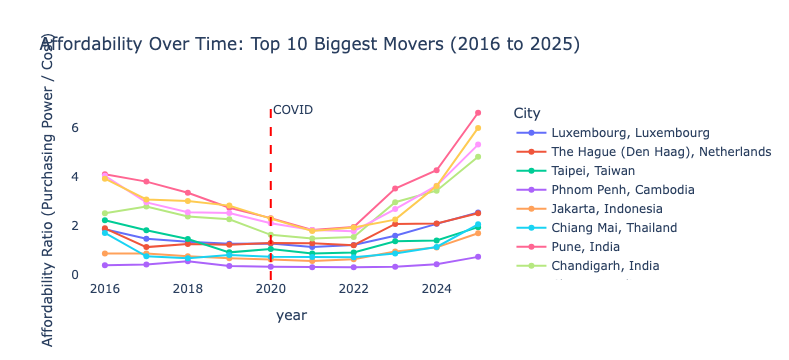

In [35]:
# 8.6 Line chart of affordability over time for biggest movers
top_movers = af_change.reindex(
    af_change['pct_change'].abs().nlargest(10).index
)['City'].tolist()

trend = df_consistent[df_consistent['City'].isin(top_movers)]

fig = px.line(
    trend,
    x='year',
    y='affordability',
    color='City',
    title='Affordability Over Time: Top 10 Biggest Movers (2016 to 2025)',
    markers=True,
    labels={'affordability': 'Affordability Ratio (Purchasing Power / Cost)'}
)
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [36]:
# 8.7 Rank shifts since COVID: which cities became relatively more or less expensive?
pre_rank  = df_consistent[df_consistent['year'] == 2019][['City', 'cost_rank']].rename(columns={'cost_rank': 'rank_2019'})
post_rank = df_consistent[df_consistent['year'] == 2025][['City', 'cost_rank']].rename(columns={'cost_rank': 'rank_2025'})

rank_shift = pd.merge(pre_rank, post_rank, on='City')
# Positive rank_change = moved up (became relatively more expensive)
rank_shift['rank_change'] = rank_shift['rank_2019'] - rank_shift['rank_2025']

print('Cities that became relatively MORE expensive since COVID (biggest rank climbers):')
print(rank_shift.sort_values('rank_change', ascending=False).head(10).to_string(index=False))

print('\nCities that became relatively CHEAPER since COVID (biggest rank droppers):')
print(rank_shift.sort_values('rank_change').head(10).to_string(index=False))

Cities that became relatively MORE expensive since COVID (biggest rank climbers):
                                     City  rank_2019  rank_2025  rank_change
                         Yerevan, Armenia        372        184          188
                        Monterrey, Mexico        354        182          172
                  Buenos Aires, Argentina        350        186          164
                         Tbilisi, Georgia        394        236          158
                          Tirana, Albania        330        173          157
                         Novi Sad, Serbia        358        205          153
                       Colombo, Sri Lanka        375        223          152
Queretaro (Santiago de Querétaro), Mexico        371        221          150
                      Mexico City, Mexico        350        200          150
                           Ankara, Turkey        361        217          144

Cities that became relatively CHEAPER since COVID (biggest rank droppe

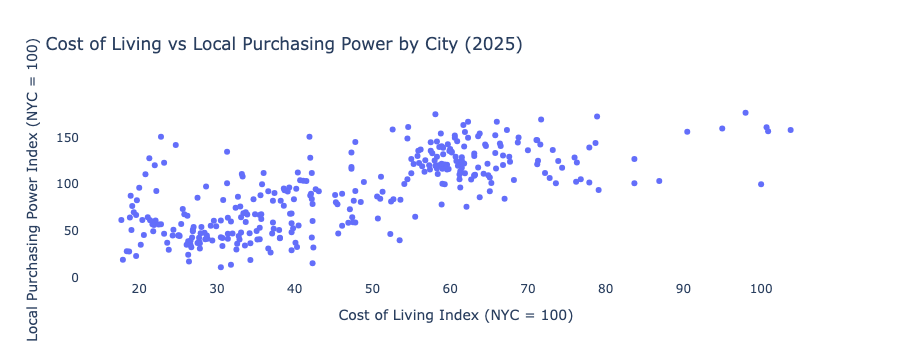

In [19]:
# 8.8 Cost vs purchasing power scatter: 2025 snapshot
fig = px.scatter(
    latest,
    x='Cost of Living Index',
    y='Local Purchasing Power Index',
    hover_name='City',
    title='Cost of Living vs Local Purchasing Power by City (2025)',
    labels={
        'Cost of Living Index': 'Cost of Living Index (NYC = 100)',
        'Local Purchasing Power Index': 'Local Purchasing Power Index (NYC = 100)'
    }
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()